# Graph cuts: move many integer labels together

How can a binary cut decide which pixels should gain a whole turn?

We start with numbers that can be checked by hand, draw the algorithm’s decision, then run the public API on data with known truth. All phase values are in radians unless stated otherwise.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd().resolve()
if not (ROOT / 'src' / 'parvaneh').is_dir(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
import parvaneh as pv
plt.rcParams.update({'figure.dpi': 115, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
def W(x): return (np.asarray(x)+np.pi) % (2*np.pi)-np.pi
def table(headers, rows):
    display(Markdown('| '+' | '.join(headers)+' |\n|'+
        '|'.join(['---']*len(headers))+'|\n'+
        '\n'.join('| '+' | '.join(map(str,r))+' |' for r in rows)))
def images(arrays, titles, cmap='viridis'):
    fig,axes=plt.subplots(1,len(arrays),figsize=(4*len(arrays),3.4),constrained_layout=True)
    for ax,a,title in zip(np.atleast_1d(axes),arrays,titles):
        im=ax.imshow(a,cmap=cmap); ax.set(title=title,xlabel='column',ylabel='row')
        fig.colorbar(im,ax=ax,shrink=.75)
    plt.show()
def align(u,t): return u-np.mean(u-t)
def scene():
    y,x=np.mgrid[0:18,0:22]
    truth=.38*x+.22*y+1.4*np.exp(-((x-12)**2+(y-8)**2)/25)
    patch=(x>=8)&(x<=14)&(y>=5)&(y<=12)
    rng=np.random.default_rng(21)
    phase=W(truth+rng.normal(size=truth.shape)*np.where(patch,1.35,.06))
    confidence=np.where(patch,.2,1.)
    return truth,phase,confidence
def report(u,t,w):
    assert u.shape==t.shape and np.isfinite(u).all()
    table(['Quantity','Measured value'],[
        ['Aligned RMSE (rad)',f'{pv.rmse_aligned(u,t):.6f}'],
        ['Raw max wrapped difference from input (rad)',f'{np.max(np.abs(W(u-w))):.6f}']])
    images([align(u,t),align(u,t)-t],['Aligned reconstruction (rad)','Error against truth (rad)'])

## 1 · Work through the model

Write $u_p=w_p+2\pi K_p$ with integer labels $K_p$. The implemented objective is
$E(K)=\sum_{ab}c_{ab}|w_b-w_a+2\pi(K_b-K_a)|^p$.
This penalizes **corrected phase steps**, not least-squares residuals $Du-g$.

For a move $K'=K+s x$, each $x_p$ is 0 or 1. An edge has four possible costs:
$V(d),V(d+2\pi s),V(d-2\pi s),V(d)$ for $(x_a,x_b)=(0,0),(0,1),(1,0),(1,1)$.
Convex $V$ gives a submodular binary problem represented by a cut.

1. Build the current pairwise label energy.
2. Find the best simultaneous binary move for a scheduled turn step.
3. Accept energy-reducing moves; repeat steps and sweeps.
4. Return integer labels as a phase field and report termination.

| Move (a,b) | New difference | Cost p=1 |
|---|---|---|
| (0, 0) | -5.700 | 5.700 |
| (0, 1) | 0.583 | 0.583 |
| (1, 0) | -11.983 | 11.983 |
| (1, 1) | -5.700 | 5.700 |

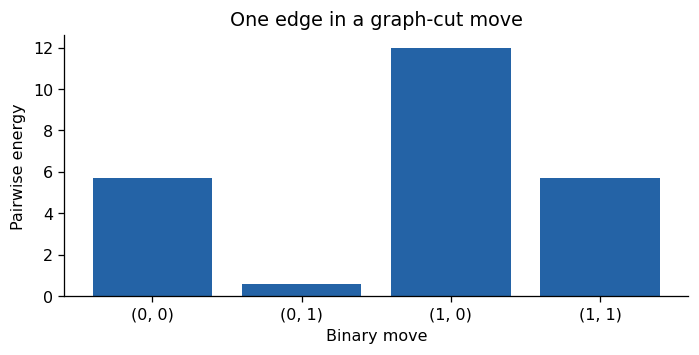

In [2]:
d=-5.7; span=2*np.pi; states=[(0,0),(0,1),(1,0),(1,1)]
costs=[abs(d+span*(b-a)) for a,b in states]
table(['Move (a,b)','New difference','Cost p=1'],
      [(str((a,b)),f'{d+span*(b-a):.3f}',f'{v:.3f}') for (a,b),v in zip(states,costs)])
assert costs[0]+costs[3]<=costs[1]+costs[2]+1e-12
fig,ax=plt.subplots(figsize=(7,3)); ax.bar([str(s) for s in states],costs,color='#2463a6')
ax.set(xlabel='Binary move',ylabel='Pairwise energy',title='One edge in a graph-cut move'); plt.show()

## 2 · Read the calculation

Moving both endpoints changes no difference, while moving only the second
endpoint can remove a wrap jump. The cut chooses many endpoints together.
Do not equate this energy with $\sum c|k|$: generally
$|g+2\pi k|\ne2\pi|k|$. Likewise $p=2$ here is not the real-valued
least-squares gradient-fitting objective.

## 3 · Run the implementation

The seed and input sizes below are fixed. A low objective or a converged solver means the chosen mathematical problem was solved; it does not prove the physical phase was recovered.

GraphCutInfo(backend='graph-cut', p=1.0, shape=(18, 22), pixels=396, nodes=396, edges=752, components=1, cuts=6, accepted=2, passes=2, max_step=2, max_jump=1, initial_objective=452.9533301915199, objective=214.40063024991943, total_variation=214.40063024991943, proven=False)


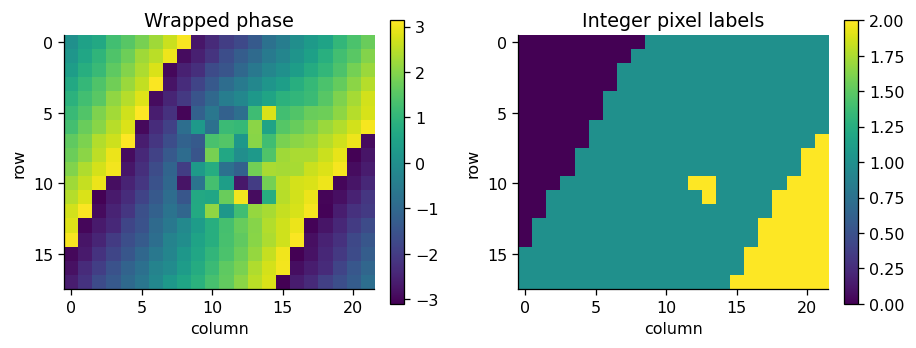

| Quantity | Measured value |
|---|---|
| Aligned RMSE (rad) | 0.411490 |
| Raw max wrapped difference from input (rad) | 0.000000 |

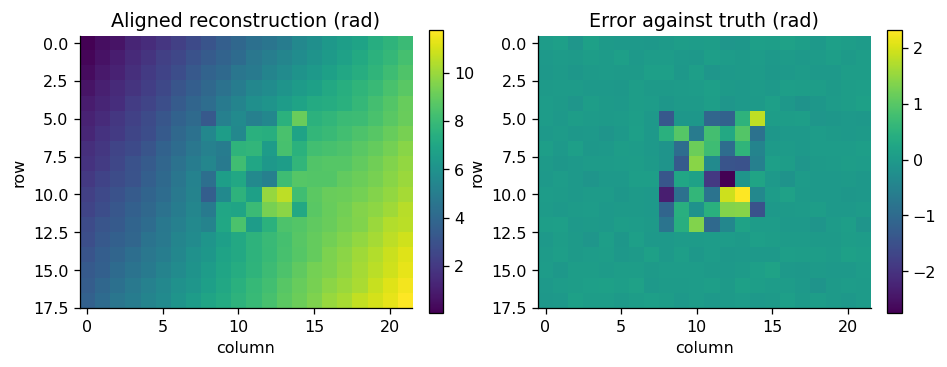

In [3]:
truth,phase,confidence=scene()
u,info=pv.puma_unwrap(phase,weight=confidence,p=1,max_jump=2,return_info=True)
print(info); images([phase,np.rint((u-phase)/(2*np.pi))],['Wrapped phase','Integer pixel labels'])
report(u,truth,phase)

## 4 · Change one choice and measure its effect

This controlled experiment changes a solver setting, data condition, or reference calculation. Compare the measured values before drawing a conclusion.

In [4]:
rows=[]
for p in [1.,2.]:
    value,info=pv.puma_unwrap(phase,p=p,max_jump=2,return_info=True)
    rows.append([p,f'{pv.rmse_aligned(value,truth):.4f}'])
    print(info)
table(['p','Aligned RMSE'],rows)
v=W(.4*np.indices((3,4,5)).sum(axis=0))
out=pv.puma_unwrap(v); assert out.shape==v.shape and np.allclose(W(out-v),0)
print('Volume shape:',out.shape)

GraphCutInfo(backend='graph-cut', p=1.0, shape=(18, 22), pixels=396, nodes=396, edges=752, components=1, cuts=6, accepted=2, passes=2, max_step=2, max_jump=1, initial_objective=578.3703359238634, objective=327.7295804913485, total_variation=327.7295804913485, proven=False)


GraphCutInfo(backend='graph-cut', p=2.0, shape=(18, 22), pixels=396, nodes=396, edges=752, components=1, cuts=6, accepted=2, passes=2, max_step=2, max_jump=1, initial_objective=1880.174941524751, objective=305.3526296107808, total_variation=327.7295804913485, proven=False)


| p | Aligned RMSE |
|---|---|
| 1.0 | 0.4115 |
| 2.0 | 0.4115 |

Volume shape: (3, 4, 5)


## 5 · Interpretation and limits

The API accepts at least two axes, including volumes. `max_jump` bounds a move
step, not the total number of turns in a label. A finite sweep budget is a
termination condition, not by itself a global-optimality certificate. Zero
confidence removes samples and returns NaN there. The default gauge keeps a
reference pixel; other gauges can alter the absolute wrapped origin.

## Continue exploring

Rerun with another seed or a larger phase step. Predict which assumption fails first, then inspect the result and report. The method’s output convention and masks matter as much as its RMSE.

Implementation: [`graph_cut.py`](../src/parvaneh/graph_cut.py). See the [API reference](../docs/api.md), [notebook index](../docs/notebooks.md), [mathematical derivations](../docs/mathematics.md), and [bibliography](../docs/references.md) for further reading. These examples describe the current implementation, including its limitations; they are not claims of numerical identity with external software.